In [1]:
%load_ext autoreload
%autoreload 2

# Пример инференса FeatureTransformer модели через FMLib

In [2]:
import os
import warnings

import pyarrow as pa
import pyarrow.fs as fs
import torch
from tqdm.autonotebook import tqdm

from fmlib.data.io import ParquetDataset
from fmlib.data.io.writer import PartitionedParquetWriter
from fmlib.nn.transforms import make_for_feature_transformer
from fmlib.pipeline import InferencePipeline
from fmlib.utils.loading import instantiate_model, load_config, load_model
from fmlib.utils.mode_context import mode_context

## Создание `ParquetDataset`
### Необходим для чтения файла по заданной структуре в метаданных. Позволяет загрузить датасет в оперативную память частями, а не полностью

In [3]:
model_folder = "configs/inference/feature_transformer"
device = "cuda:0"

_, metadata = load_config(model_folder, config_file="parquet_metadata.yaml")

dataloader = ParquetDataset(
    source="/user/team/team_ai_avatar/avatar_fm/examples/campaign_demo/td_processed/test",
    metadata=metadata,
    partition_size=4096,
    batch_size=512,
    filesystem=fs.HadoopFileSystem("hdfs://arnsdpsbx", port=0),
    device=device,
)

### Получение батча

In [4]:
batch = next(iter(dataloader))
batch.keys()

dict_keys(['bucket_num_mask', 'bucket_num', 'epk_id_mask', 'epk_id', 'target_attr_1_mask', 'target_attr_1', 'target_attr_2_mask', 'target_attr_2', 'target_attr_3_mask', 'target_attr_3', 'cat_features_mask', 'cat_features', 'num_features_mask', 'num_features', 'seq_hidden_state_mask', 'seq_hidden_state'])

## Инициализация Transform класса
### Этот класс необходим для обработки батча перед подачей в модель. Обратите внимание, что обработка может работать на GPU, это зависит от передаваемых в `Transform` тензоров
### Примеры операций, которые могут применяться в Transform:
- Фильтрация элементов
- Определение масок и маскирование
- Переименование/перегруппировка тензоров для совместимости с моделью
- Обработка вещественных значений - бакетизация, дискретизация
- Обработка категориальных значений - энкодинг

In [5]:
transform = make_for_feature_transformer()
test_transformed = transform(batch)
test_transformed.keys()

dict_keys(['cat_features', 'cat_features_mask', 'epk_id', 'epk_id_mask', 'hidden_states', 'num_features', 'num_features_mask'])

### Загрузка модели в формате PyTorch
#### Для успешной загрузки необходимо указать путь до папки. В папке должна лежать вся информация необходимая для загрузки модели - веса и конфиг.
#### Рекомендуется, чтобы веса модели были сохранены в формате safetensors

In [6]:
checkpoint_path = os.path.join(model_folder, "model.bin")
if os.path.exists(checkpoint_path):
    torch_model = load_model(model_folder)
else:
    warnings.warn("Fake checkpoint will be produced.", stacklevel=2)
    torch_model = instantiate_model(model_folder)

## Создадим объект класса `InferencePipeline`
#### Пайплайн будет отвечать за трансформацию данных и подачу этих данных в модель.
#### В результате работы пайплайна вы получите преобразованный батч после применения Transform'ов и результат работы модели.
#### Обратите внимание, что `InferencePipeline` может принимать несколько Transform'ов. В таком случае будет выведен результат работы для каждого Transform отдельно (массив результатов)
#### Класс `InferencePipeline` является наследником `torch.nn.Module`. Поэтому вы свободно можете применять `torch.compile` к нему

In [7]:
pipeline = InferencePipeline(model=torch_model, transform=transform).to(device)

In [8]:
with torch.no_grad(), mode_context(pipeline, training=False):
    transformed_batch, model_logits = pipeline(batch)

In [9]:
model_logits

[{'logits': tensor([[-0.5421, -0.6889],
          [-0.8287, -0.0811],
          [-0.4635, -0.7698],
          ...,
          [-1.6270, -0.0536],
          [-0.9066, -0.8509],
          [-0.6085,  0.3285]], device='cuda:0')}]

## Пример запуска полного цикла инференса и побатчевая запись результата в `parquet`

In [10]:
import tempfile

directory = tempfile.TemporaryDirectory()

In [11]:
writer = PartitionedParquetWriter(base_path=f"{directory.name}/result", write_every_n_batch=8)

## Inference Loop

In [12]:
with torch.no_grad(), mode_context(pipeline, training=False):
    for batch in tqdm(dataloader):
        transformed, model_logits = pipeline(batch)
        result = model_logits[0]
        result["logits"] = torch.nn.functional.softmax(result["logits"], dim=-1)
        result["epk_id"] = batch["epk_id"]
        writer.write(result)

  0%|          | 0/1488 [00:00<?, ?it/s]

In [13]:
writer.close()
writer.base_path

'/tmp/tmp8bjfv8f2/result'

### Визуализация скоров

#### Для запуска понадобится установка библиотеки `matplotlib`

In [14]:
import matplotlib.pyplot as plt

In [15]:
data = pa.parquet.read_table(writer.base_path)
scores = torch.asarray(data.column("logits").to_pylist())

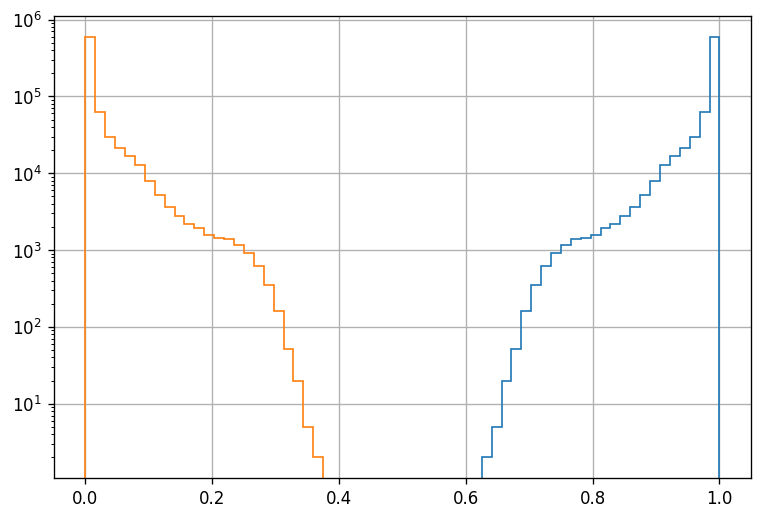

In [16]:
_ = plt.figure(figsize=(7.5, 5), dpi=120)
_ = plt.hist(scores[:, 0], range=(0, 1), bins=64, histtype="step")
_ = plt.hist(scores[:, 1], range=(0, 1), bins=64, histtype="step")
_ = plt.yscale("log", base=10)
_ = plt.grid()